### 4.2 Dataset Preparation 

In [11]:
import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

In [12]:
BATCH_SIZE = 64

transform = transforms.Compose([
    transforms.ToTensor(),
])


# Loading the training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)


test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("--- Training Data Batch ---")
train_data_iter = iter(train_loader)
train_images, train_labels = next(train_data_iter)
print(f"Image batch shape: {train_images.shape}")
print(f"Label batch shape: {train_labels.shape}")

print("\n--- Test Data Batch ---")
test_data_iter = iter(test_loader)
test_images, test_labels = next(test_data_iter)
print(f"Image batch shape: {test_images.shape}")
print(f"Label batch shape: {test_labels.shape}")

--- Training Data Batch ---
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])

--- Test Data Batch ---
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


### 4.3 Model Architecture

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim, h_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, h_dim)
        self.fc_mu = nn.Linear(h_dim, latent_dim)
        self.fc_log_var = nn.Linear(h_dim, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, h_dim)
        self.fc4 = nn.Linear(h_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var
    
    def decode(self, z):
        h = F.relu(self.fc3(z))
        x_hat = F.sigmoid(self.fc4(h))
        return x_hat
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)
        z = mu + epsilon * std
        return z
    
    def forward(self, x):
        
        batch_size = x.shape[0]
        x = x.view(batch_size, -1)
        
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_hat = self.decode(z)
        return x_hat, mu, log_var


Experiment with different latent dimensions and network depths, and discuss how these
changes influence the smoothness of the latent space and reconstruction fidelity.

### 4.4 Loss Function

In [ ]:
def loss_function(x_hat, x, mu, logvar, beta):
    BCE = F.binary_cross_entropy(x_hat, x.view(-1, 784), reduction='sum')

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + beta * KLD, BCE, KLD

Explain the role of each term in shaping the learned latent representation.

In [ ]:
vae = VAE(input_dim=784, h_dim=400, latent_dim=20)
x_hat, mu, log_var = vae.forward(test_dataset[0][0].view(-1, 784))

print(x_hat.shape)
print(mu.shape)
print(log_var.shape)

torch.Size([1, 784])
torch.Size([1, 20])
torch.Size([1, 20])


#### Train your model using an optimizer of your choice (e.g., Adam).
• Plot the total loss and its components over epochs.

### 4.5 Training Procedure 

====> Epoch: 1 Average loss: 274.4735
====> Epoch: 2 Average loss: 251.5362
====> Epoch: 3 Average loss: 247.4980
====> Epoch: 4 Average loss: 245.6410
====> Epoch: 5 Average loss: 244.5260
====> Epoch: 6 Average loss: 243.6941
====> Epoch: 7 Average loss: 243.0277
====> Epoch: 8 Average loss: 242.5591
====> Epoch: 9 Average loss: 242.1165
====> Epoch: 10 Average loss: 241.7326
====> Epoch: 11 Average loss: 241.4341
====> Epoch: 12 Average loss: 241.1353
====> Epoch: 13 Average loss: 240.9586
====> Epoch: 14 Average loss: 240.7432
====> Epoch: 15 Average loss: 240.5427
====> Epoch: 16 Average loss: 240.4460
====> Epoch: 17 Average loss: 240.2494
====> Epoch: 18 Average loss: 240.1193
====> Epoch: 19 Average loss: 240.0264
====> Epoch: 20 Average loss: 239.8732


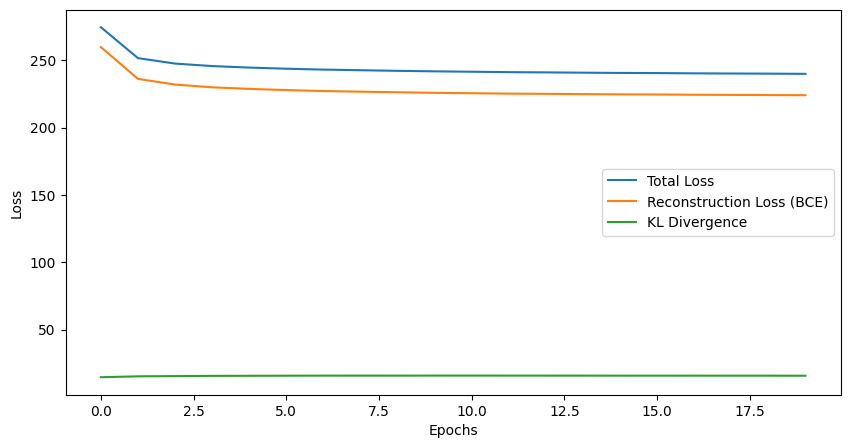

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = VAE(input_dim=784, h_dim=400, latent_dim=20).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train(epoch):
    model.train()
    train_loss = 0
    total_bce = 0
    total_kld = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss, bce, kld = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()
        optimizer.step()
        
    avg_loss = train_loss / len(train_loader.dataset)
    avg_bce = total_bce / len(train_loader.dataset)
    avg_kld = total_kld / len(train_loader.dataset)
    
    print(f'====> Epoch: {epoch} Average loss: {avg_loss:.4f}')
    return avg_loss, avg_bce, avg_kld

epochs = 20
losses = []
bces = []
klds = []

for epoch in range(1, epochs + 1):
    loss, bce, kld = train(epoch)
    losses.append(loss)
    bces.append(bce)
    klds.append(kld)

plt.figure(figsize=(10, 5))
plt.plot(losses, label='Total Loss')
plt.plot(bces, label='Reconstruction Loss (BCE)')
plt.plot(klds, label='KL Divergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()